# Modelo: Support Vector Machine (SVM)
**Dataset:** Sonar – Classificação de Minas vs Rochas  
**Algoritmo:** SVC (scikit-learn)  
**Parâmetros:** kernel=rbf | C=1.0 | gamma=scale  
**Split:** 75% treino / 25% teste | random_state=42  
**Normalização:** StandardScaler

## 1. Importações e Configuração

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve
)
# Bibliotecas de monitoramento de performance computacional
import time
import tracemalloc
import platform
import psutil
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

### MLflow — Configuração

In [13]:
### MLflow — Configuração
import mlflow
import mlflow.sklearn
import subprocess, time, os, requests
import warnings
warnings.filterwarnings("ignore")

MLFLOW_PORT    = 5000
MLFLOW_DIR     = os.path.expanduser("../mlflow-local")
DB_PATH        = os.path.join(MLFLOW_DIR, "mlflow.db")
ARTIFACT_DIR   = os.path.join(MLFLOW_DIR, "artifacts")
EXPERIMENT_NAME = "narwhal"

os.makedirs(ARTIFACT_DIR, exist_ok=True)

def server_running():
    try:
        return requests.get(f"http://localhost:{MLFLOW_PORT}/health", timeout=2).status_code == 200
    except Exception:
        return False

if server_running():
    print(f"✅ Servidor MLflow já rodando → http://localhost:{MLFLOW_PORT}")
else:
    log = open(os.path.join(MLFLOW_DIR, "server.log"), "w")
    proc = subprocess.Popen(
        ["mlflow", "server",
         "--host", "127.0.0.1", "--port", str(MLFLOW_PORT),
         "--backend-store-uri", f"sqlite:///{DB_PATH}",
         "--default-artifact-root", ARTIFACT_DIR],
        stdout=log, stderr=log
    )
    print(f"Iniciando servidor MLflow (PID {proc.pid})...")
    for _ in range(20):
        time.sleep(1)
        if server_running():
            break
    if server_running():
        print(f"Servidor MLflow rodando → http://localhost:{MLFLOW_PORT}")
    else:
        print("Falha ao iniciar. Veja ~/mlflow-local/server.log")

# ── Conecta e cria/reutiliza o experimento ─────────────────────────────────────
mlflow.set_tracking_uri(f"http://localhost:{MLFLOW_PORT}")
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Experimento: '{EXPERIMENT_NAME}'")


✅ Servidor MLflow já rodando → http://localhost:5000
Experimento: 'narwhal'


## 2. Carregamento dos Dados

In [14]:
PATH = r"../../sonar_data_matriz.csv"

dataset = pd.read_csv(PATH, header=None)
print("Shape:", dataset.shape)
print("\nDistribuição de classes:")
print(dataset.iloc[:, -1].value_counts())
dataset.head()

Shape: (208, 61)

Distribuição de classes:
60
M    111
R     97
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,0.1609,0.1582,0.2238,0.0645,0.0660,0.2273,0.3100,0.2999,0.5078,0.4797,0.5783,0.5071,0.4328,0.5550,0.6711,0.6415,0.7104,0.8080,0.6791,0.3857,0.1307,0.2604,0.5121,0.7547,0.8537,0.8507,0.6692,0.6097,0.4943,0.2744,0.0510,0.2834,0.2825,0.4256,0.2641,0.1386,0.1051,0.1343,0.0383,0.0324,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,0.4918,0.6552,0.6919,0.7797,0.7464,0.9444,1.0000,0.8874,0.8024,0.7818,0.5212,0.4052,0.3957,0.3914,0.3250,0.3200,0.3271,0.2767,0.4423,0.2028,0.3788,0.2947,0.1984,0.2341,0.1306,0.4182,0.3835,0.1057,0.1840,0.1970,0.1674,0.0583,0.1401,0.1628,0.0621,0.0203,0.0530,0.0742,0.0409,0.0061,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,0.6333,0.7060,0.5544,0.5320,0.6479,0.6931,0.6759,0.7551,0.8929,0.8619,0.7974,0.6737,0.4293,0.3648,0.5331,0.2413,0.5070,0.8533,0.6036,0.8514,0.8512,0.5045,0.1862,0.2709,0.4232,0.3043,0.6116,0.6756,0.5375,0.4719,0.4647,0.2587,0.2129,0.2222,0.2111,0.0176,0.1348,0.0744,0.0130,0.0106,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,0.0881,0.1992,0.0184,0.2261,0.1729,0.2131,0.0693,0.2281,0.4060,0.3973,0.2741,0.3690,0.5556,0.4846,0.3140,0.5334,0.5256,0.2520,0.2090,0.3559,0.6260,0.7340,0.6120,0.3497,0.3953,0.3012,0.5408,0.8814,0.9857,0.9167,0.6121,0.5006,0.3210,0.3202,0.4295,0.3654,0.2655,0.1576,0.0681,0.0294,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,0.4152,0.3952,0.4256,0.4135,0.4528,0.5326,0.7306,0.6193,0.2032,0.4636,0.4148,0.4292,0.5730,0.5399,0.3161,0.2285,0.6995,1.0000,0.7262,0.4724,0.5103,0.5459,0.2881,0.0981,0.1951,0.4181,0.4604,0.3217,0.2828,0.2430,0.1979,0.2444,0.1847,0.0841,0.0692,0.0528,0.0357,0.0085,0.0230,0.0046,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## 3. Pré-processamento e Normalização

In [15]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Codificação: M=1 (Mina), R=0 (Rocha)
y = np.where(y == 'M', 1, 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# SVM é sensível à escala — normalização obrigatória
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Treino : {X_train_s.shape[0]} amostras  |  Teste: {X_test_s.shape[0]} amostras")
print(f"Classes: 0=Rocha, 1=Mina")
print("Normalização: StandardScaler aplicado")

Treino : 156 amostras  |  Teste: 52 amostras
Classes: 0=Rocha, 1=Mina
Normalização: StandardScaler aplicado


## 4. Busca de Hiperparâmetros (GridSearchCV)

Exploração dos principais parâmetros do SVM (C e gamma) usando validação cruzada para encontrar a melhor configuração.

In [16]:
param_grid = {
    'C'     : [0.1, 1, 10, 100],
    'gamma' : ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_s, y_train)

print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)
print(f"\nMelhor acurácia CV (GridSearch): {grid_search.best_score_:.4f}")

Melhores parâmetros encontrados:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Melhor acurácia CV (GridSearch): 0.8333


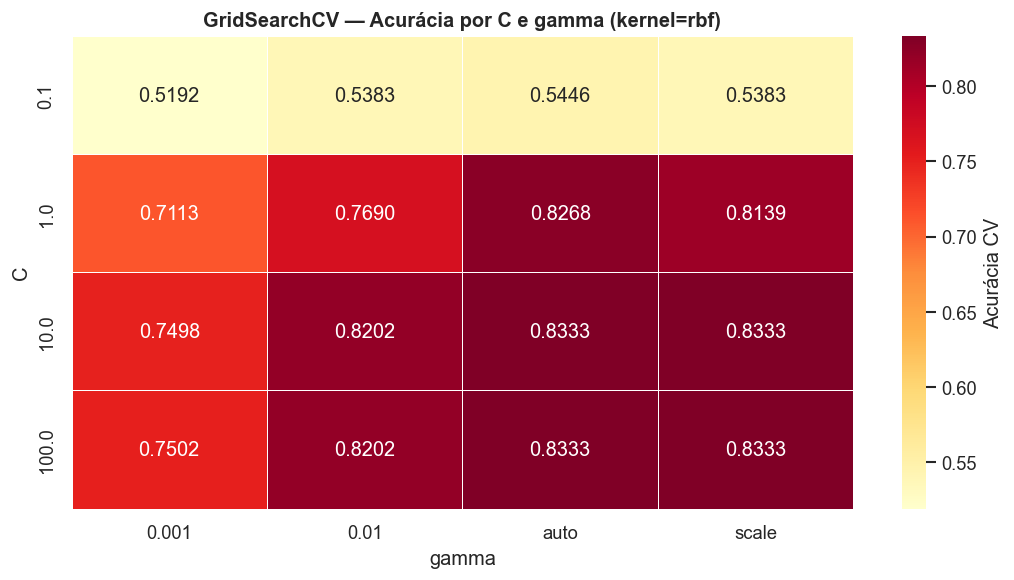

In [17]:
# Visualização do impacto de C e gamma (kernel=rbf)
results_df = pd.DataFrame(grid_search.cv_results_)
rbf_results = results_df[results_df['param_kernel'] == 'rbf'].copy()

pivot_data = rbf_results.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Acurácia CV'})
ax.set_title('GridSearchCV — Acurácia por C e gamma (kernel=rbf)', fontweight='bold')
ax.set_xlabel('gamma')
ax.set_ylabel('C')
plt.tight_layout()
_gridsearch_path = '../../images/svm/svm_gridsearch.png'
plt.savefig(_gridsearch_path, bbox_inches='tight')
plt.show()

## 5. Treinamento do Modelo

In [18]:
PARAMS = {
    'kernel' : 'rbf',
    'C'      : 1.0,
    'gamma'  : 'scale',
    'probability': True, # necessário para predict_proba e ROC-AUC
    'random_state': 42
}

# ── Inicia a run do MLflow ────────────────────────────────────────────────────
name = f"svm-{PARAMS['kernel']}-c{int(PARAMS['C'])}-g{PARAMS['gamma']}"
run = mlflow.start_run(run_name=name)
print(f"Run iniciada: {run.info.run_id[:12]}…")

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  SVC(**PARAMS))
])

pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Loga parâmetros imediatamente após o treino
mlflow.log_params(PARAMS)
mlflow.set_tag("dataset",   "sonar_data_matriz.csv")
mlflow.set_tag("framework", "scikit-learn")
mlflow.set_tag("split",     "75/25")

print("Modelo treinado | Parâmetros logados no MLflow")
print(f"Vetores de suporte: {pipeline.named_steps['model'].n_support_} (classe 0 / classe 1)")

mlflow.sklearn.log_model(
    sk_model=pipeline,
    name=name
)

2026/06/23 12:21:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run iniciada: de662536129c…
Modelo treinado | Parâmetros logados no MLflow
Vetores de suporte: [60 64] (classe 0 / classe 1)


In [19]:
# ── Salva gráfico do GridSearch como artefato ─────────────────────────
mlflow.log_artifact(_gridsearch_path, artifact_path="graficos")
print("Gráfico do GridSearch como artefato")

Gráfico do GridSearch como artefato


## 6. Métricas de Desempenho

In [20]:
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

metricas = {
    "Acurácia"         : acc,
    "Precisão (Mina)"  : precision,
    "Recall (Mina)"    : recall,
    "F1-Score (Mina)"  : f1,
    "ROC-AUC"          : roc_auc,
    "CV Acurácia (5x)" : cv_scores.mean(),
}

df_metricas = pd.DataFrame(metricas.items(), columns=["Métrica", "Valor"])
df_metricas["Valor"] = df_metricas["Valor"].map(lambda v: f"{v:.4f}")
print("=== MÉTRICAS – SVM ===")
display(df_metricas)

# ── Loga métricas no MLflow ───────────────────────────────────────────────────
mlflow.log_metrics({
    "accuracy"       : round(acc, 4),
    "precision"      : round(precision, 4),
    "recall"         : round(recall, 4),
    "f1_score"       : round(f1, 4),
    "roc_auc"        : round(roc_auc, 4),
    "cv_accuracy_mean": round(cv_scores.mean(), 4),
    "cv_accuracy_std" : round(cv_scores.std(), 4),
})
print("Métricas logadas no MLflow")

=== MÉTRICAS – SVM ===


,Métrica,Valor
0,Acurácia,0.9038
1,Precisão (Mina),0.9630
2,Recall (Mina),0.8667
3,F1-Score (Mina),0.9123
4,ROC-AUC,0.9682
5,CV Acurácia (5x),0.6393


Métricas logadas no MLflow


## 7. Performance Computacional

Métricas de uso de CPU, memória RAM e tempo de execução coletadas durante o treinamento e a inferência do modelo.

In [21]:
# Informações do ambiente
print("=== AMBIENTE DE EXECUÇÃO ===")
print(f"  SO          : {platform.system()} {platform.release()}")
print(f"  Processador : {platform.processor() or platform.machine()}")
print(f"  Núcleos CPU : {psutil.cpu_count(logical=False)} físicos / {psutil.cpu_count()} lógicos")
print(f"  RAM total   : {psutil.virtual_memory().total / 1e9:.2f} GB")
print(f"  Python      : {platform.python_version()}")

# CPU e RAM antes do treino
cpu_antes = psutil.cpu_percent(interval=0.5)
proc      = psutil.Process(os.getpid())
ram_antes = proc.memory_info().rss / 1e6  # MB

# Treino com medição de tempo e memória
tracemalloc.start()
t0_treino = time.perf_counter()

_pipeline_perf = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  SVC(**PARAMS))
])
_pipeline_perf.fit(X_train, y_train)

t1_treino = time.perf_counter()
mem_pico_treino, _ = tracemalloc.get_traced_memory()
tracemalloc.stop()

tempo_treino       = t1_treino - t0_treino
mem_pico_treino_mb = mem_pico_treino / 1e6

# Inferência com medição de tempo
t0_inf = time.perf_counter()
_ = _pipeline_perf.predict(X_test)
t1_inf = time.perf_counter()
tempo_inferencia  = t1_inf - t0_inf
tempo_por_amostra = tempo_inferencia / len(X_test) * 1000  # ms

# CPU e RAM depois
cpu_depois = psutil.cpu_percent(interval=0.5)
ram_depois = proc.memory_info().rss / 1e6

# Tabela de resultados
df_perf = pd.DataFrame({
    "Métrica": [
        "Tempo de Treino (s)",
        "Tempo de Inferência (s)",
        "Tempo por Amostra (ms)",
        "Pico de Memória — Treino (MB)",
        "RAM do Processo — Antes (MB)",
        "RAM do Processo — Depois (MB)",
        "Delta RAM (MB)",
        "CPU antes do treino (%)",
        "CPU depois do treino (%)",
        "Amostras de Treino",
        "Amostras de Teste",
        "Núcleos lógicos disponíveis",
    ],
    "Valor": [
        f"{tempo_treino:.6f}",
        f"{tempo_inferencia:.6f}",
        f"{tempo_por_amostra:.4f}",
        f"{mem_pico_treino_mb:.4f}",
        f"{ram_antes:.2f}",
        f"{ram_depois:.2f}",
        f"{ram_depois - ram_antes:.2f}",
        f"{cpu_antes:.1f}",
        f"{cpu_depois:.1f}",
        str(len(X_train)),
        str(len(X_test)),
        str(psutil.cpu_count()),
    ]
})

print("\n=== PERFORMANCE COMPUTACIONAL — SVM ===")
display(df_perf)

=== AMBIENTE DE EXECUÇÃO ===
  SO          : Windows 11
  Processador : AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD
  Núcleos CPU : 6 físicos / 12 lógicos
  RAM total   : 33.92 GB
  Python      : 3.14.2

=== PERFORMANCE COMPUTACIONAL — SVM ===


,Métrica,Valor
0,Tempo de Treino (s),0.007350
1,Tempo de Inferência (s),0.000606
2,Tempo por Amostra (ms),0.0117
3,Pico de Memória — Treino (MB),0.0766
4,RAM do Processo — Antes (MB),376.84
5,RAM do Processo — Depois (MB),376.85
6,Delta RAM (MB),0.01
7,CPU antes do treino (%),17.7
8,CPU depois do treino (%),17.5
9,Amostras de Treino,156


In [22]:
# ── Loga métricas computacionais no MLflow ────────────────────────────────────
mlflow.log_metrics({
    "system/tempo_treino_s"       : round(tempo_treino, 6),
    "system/tempo_inferencia_s"   : round(tempo_inferencia, 6),
    "system/tempo_por_amostra_ms" : round(tempo_por_amostra, 4),
    "system/mem_pico_treino_mb"   : round(mem_pico_treino_mb, 4),
    "system/delta_ram_mb"         : round(ram_depois - ram_antes, 2),
    "system/delta_cpu_percent"    : round(cpu_depois - cpu_antes, 2),
})
mlflow.set_tag("so",         f"{platform.system()} {platform.release()}")
mlflow.set_tag("cpu_nucleos", str(psutil.cpu_count()))
print("Métricas de performance logadas no MLflow")

Métricas de performance logadas no MLflow


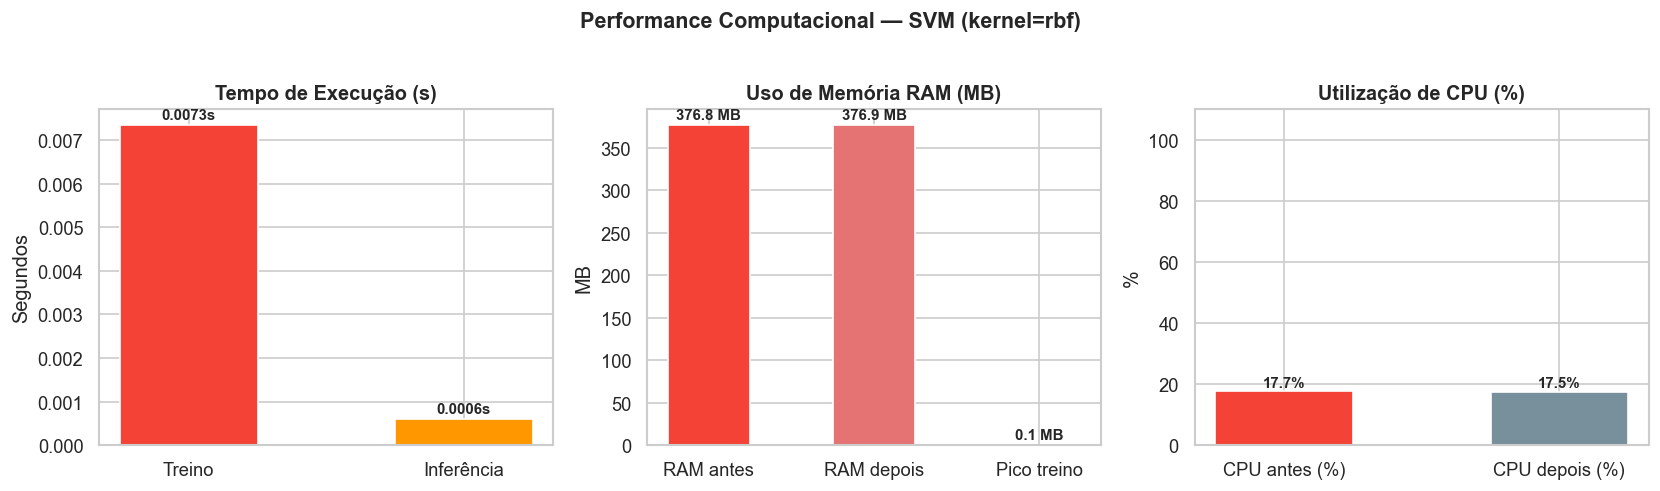

In [23]:
# ── Visualização das métricas de performance ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Tempo
labels_t = ["Treino", "Inferência"]
vals_t   = [tempo_treino, tempo_inferencia]
bars = axes[0].bar(labels_t, vals_t, color=["#F44336", "#FF9800"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_t):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + max(vals_t)*0.01,
                 f"{v:.4f}s", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Tempo de Execução (s)", fontweight="bold")
axes[0].set_ylabel("Segundos")

# 2. Memória RAM
labels_m = ["RAM antes", "RAM depois", "Pico treino"]
vals_m   = [ram_antes, ram_depois, mem_pico_treino_mb]
bars = axes[1].bar(labels_m, vals_m, color=["#F44336", "#E57373", "#FFB74D"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_m):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + max(vals_m)*0.01,
                 f"{v:.1f} MB", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_title("Uso de Memória RAM (MB)", fontweight="bold")
axes[1].set_ylabel("MB")

# 3. CPU
labels_c = ["CPU antes (%)", "CPU depois (%)"]
vals_c   = [cpu_antes, cpu_depois]
bars = axes[2].bar(labels_c, vals_c, color=["#F44336", "#78909C"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_c):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f"{v:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[2].set_ylim(0, 110)
axes[2].set_title("Utilização de CPU (%)", fontweight="bold")
axes[2].set_ylabel("%")

fig.suptitle("Performance Computacional — SVM (kernel=rbf)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Matriz de Confusão

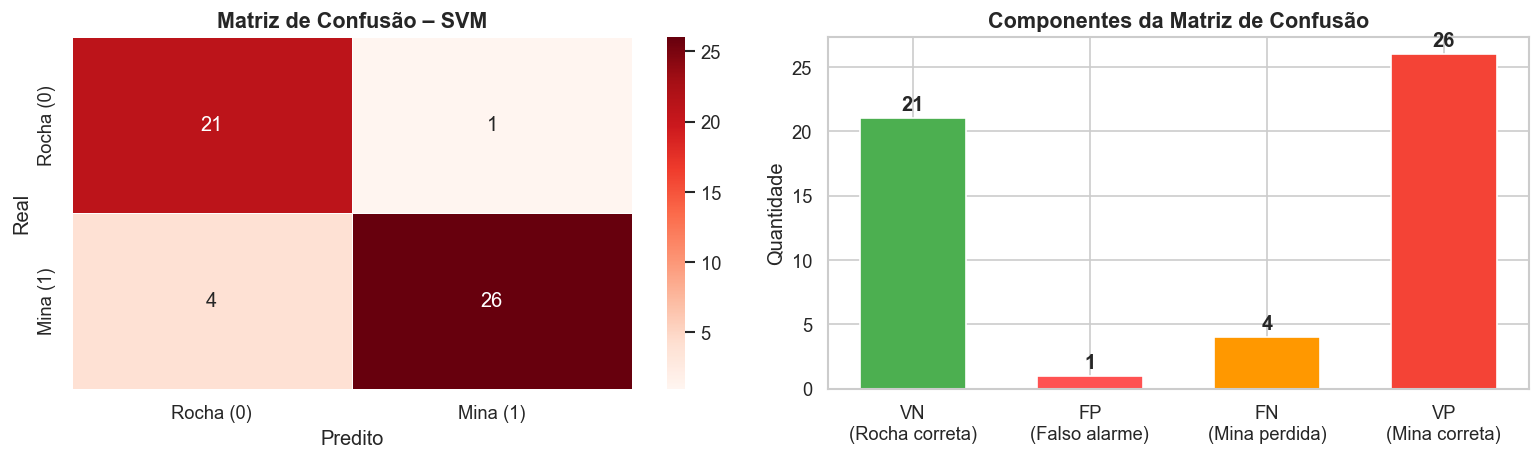


VN=21  FP=1  FN=4  VP=26


In [24]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Rocha (0)', 'Mina (1)'],
            yticklabels=['Rocha (0)', 'Mina (1)'],
            ax=axes[0], linewidths=.5)
axes[0].set_title('Matriz de Confusão – SVM', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# Barras de componentes
labels = ['VN\n(Rocha correta)', 'FP\n(Falso alarme)', 'FN\n(Mina perdida)', 'VP\n(Mina correta)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['#4CAF50', '#FF5252', '#FF9800', '#F44336']
bars = axes[1].bar(labels, values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Componentes da Matriz de Confusão', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
_cm_path = '../../images/svm/svm_matriz_confusao.png'
plt.savefig(_cm_path, bbox_inches='tight')
plt.show()

print(f"\nVN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  VP={cm[1,1]}")

In [25]:
# ── Salva a matriz de confusão como artefato MLflow ──────────────────────────
mlflow.log_artifact(_cm_path, artifact_path="graficos")
print("Matriz de confusão salva como artefato")

cm_dict = {
    "VN (Rocha correta)": int(cm[0,0]),
    "FP (Falso alarme)": int(cm[0,1]),
    "FN (Mina perdida)": int(cm[1,0]),
    "VP (Mina correta)": int(cm[1,1]),
}

mlflow.log_table(data=cm_dict, artifact_file="matriz_confusao.json")

Matriz de confusão salva como artefato


## 9. Curva ROC

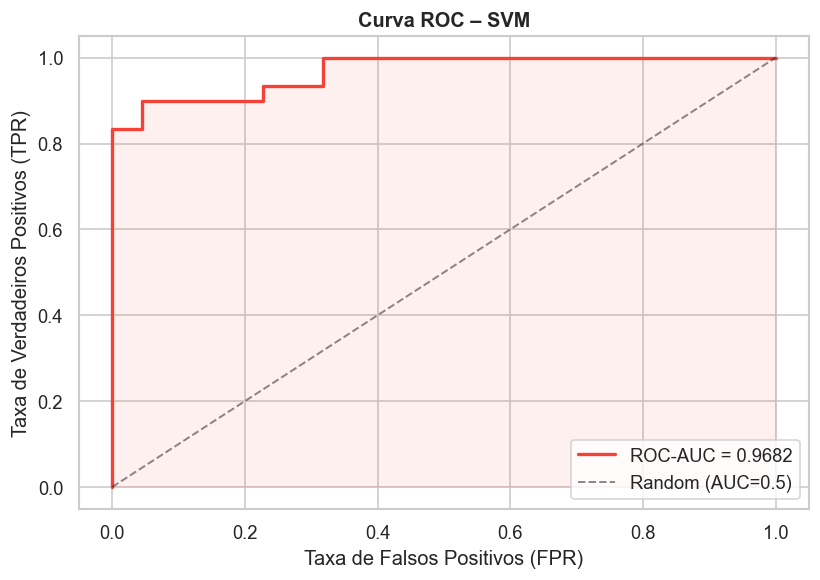

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#F44336', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5, label='Random (AUC=0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#F44336')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.set_title('Curva ROC – SVM', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
_roc_path = '../../images/svm/svm_roc.png'
plt.savefig(_roc_path, bbox_inches='tight')
plt.show()

In [27]:
# ── Salva a curva ROC como artefato MLflow ──────────────────────────
mlflow.log_artifact(_roc_path, artifact_path="graficos")
print("Curva ROC salva como artefato")

Curva ROC salva como artefato


## 10. Relatório de Classificação Completo

In [28]:
_report = classification_report(y_test, y_pred, target_names=["Rocha (0)", "Mina (1)"])
_report_path = "../../results/svm/svm_classification_report.txt"
with open(_report_path, "w") as f:
    f.write(_report)
print(_report)

              precision    recall  f1-score   support

   Rocha (0)       0.84      0.95      0.89        22
    Mina (1)       0.96      0.87      0.91        30

    accuracy                           0.90        52
   macro avg       0.90      0.91      0.90        52
weighted avg       0.91      0.90      0.90        52



In [29]:
# ── Salva o classification report como artefato de texto ─────────────────────
mlflow.log_artifact(_report_path, artifact_path="reports")
print("Classification report salvo como artefato")

Classification report salvo como artefato


## 11. Validação Cruzada (5-fold)

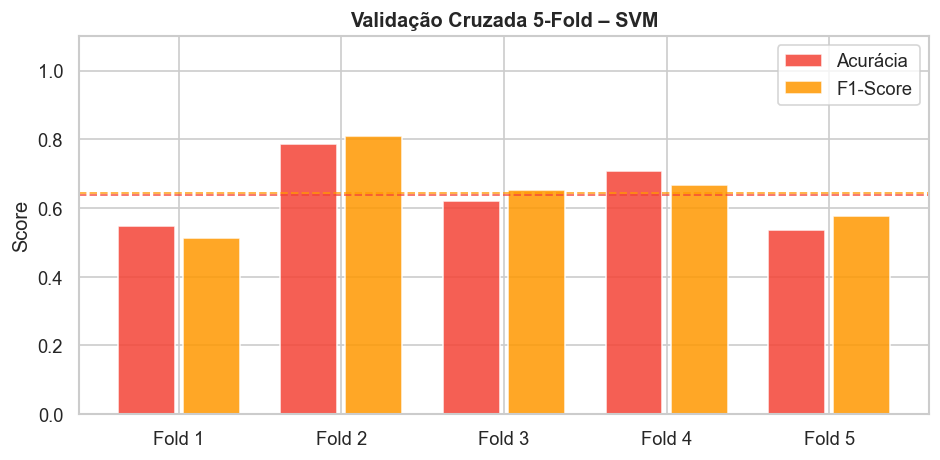

Acurácia CV  → média=0.6393  std=0.0953
F1-Score CV  → média=0.6436   std=0.0992


In [31]:
cv_acc = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
cv_f1  = cross_val_score(pipeline, X, y, cv=5, scoring='f1')

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
ax.bar(x - 0.2, cv_acc, 0.35, label='Acurácia', color='#F44336', alpha=0.85)
ax.bar(x + 0.2, cv_f1,  0.35, label='F1-Score',  color='#FF9800', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(folds)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Validação Cruzada 5-Fold – SVM', fontweight='bold')
ax.legend()
ax.axhline(cv_acc.mean(), color='#F44336', ls='--', lw=1.2, alpha=0.7)
ax.axhline(cv_f1.mean(),  color='#FF9800', ls='--', lw=1.2, alpha=0.7)
plt.tight_layout()
_cv_path = '../../images/svm/svm_cv.png'
plt.savefig(_cv_path, bbox_inches='tight')
plt.show()

print(f"Acurácia CV  → média={cv_acc.mean():.4f}  std={cv_acc.std():.4f}")
print(f"F1-Score CV  → média={cv_f1.mean():.4f}   std={cv_f1.std():.4f}")

In [32]:
# ── Salva gráfico de validação cruzada como artefato ─────────────────────────
mlflow.log_artifact(_cv_path, artifact_path="graficos")
print("Gráfico de validação cruzada salvo como artefato")

Gráfico de validação cruzada salvo como artefato


## 12. Sumário Final

In [33]:
resultados_modelo = pd.DataFrame({
    "Modelo"          : ["SVM (kernel=rbf)"],
    "Acurácia"        : [round(acc, 4)],
    "Precisão"        : [round(precision, 4)],
    "Recall"          : [round(recall, 4)],
    "F1-Score"        : [round(f1, 4)],
    "ROC-AUC"         : [round(roc_auc, 4)],
    "CV Acurácia (μ)" : [round(cv_scores.mean(), 4)],
})

dados_processamento = pd.DataFrame({
    "Tempo Treino (s)"         : [round(tempo_treino, 6)],
    "Tempo Inferência (s)"     : [round(tempo_inferencia, 6)],
    "Tempo/Amostra (ms)"       : [round(tempo_por_amostra, 4)],
    "Pico Memória Treino (MB)" : [round(mem_pico_treino_mb, 4)],
    "Delta RAM (MB)"           : [round(ram_depois - ram_antes, 2)],
})

print("=== RESULTADOS DO MODELO ===")
display(resultados_modelo)

print("=== DADOS DE PROCESSAMENTO ===")
display(dados_processamento)

resultados_modelo.to_csv("../../results/svm/resultados_modelo_svm.csv", index=False)
dados_processamento.to_csv("../../results/svm/dados_processamento_svm.csv", index=False)

print("Arquivos CSV gerados com sucesso!")

=== RESULTADOS DO MODELO ===


,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC,CV Acurácia (μ)
0,SVM (kernel=rbf),0.9038,0.963,0.8667,0.9123,0.9682,0.6393


=== DADOS DE PROCESSAMENTO ===


,Tempo Treino (s),Tempo Inferência (s),Tempo/Amostra (ms),Pico Memória Treino (MB),Delta RAM (MB)
0,0.00735,0.000606,0.0117,0.0766,0.01


Arquivos CSV gerados com sucesso!


In [34]:
mlflow.end_run()

🏃 View run svm-rbf-c1-gscale at: http://localhost:5000/#/experiments/2/runs/de662536129c46ecac91e8b19c1856fe
🧪 View experiment at: http://localhost:5000/#/experiments/2
